In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv(r"..\data\en.openfoodfacts.org.products.csv.gz", sep="\t", encoding='utf-8', nrows=10000)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_4840\3062298247.py:1: DtypeWarning: Columns (0: abbreviated_product_name, 1: packaging_text, 2: no_nutrition_data) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"..\data\en.openfoodfacts.org.products.csv.gz", sep="\t", encoding='utf-8', nrows=10000)


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
scores_connus = ['a', 'b', 'c', 'd', 'e']
df_connu = df[df['nutriscore_grade'].isin(scores_connus)].copy()

# DataFrame avec le reste (unknown, not-applicable, ou NaN éventuels)
df_inconnu = df[~df['nutriscore_grade'].isin(scores_connus)].copy()

# Vérification rapide
print("Connu :", df_connu.shape)
print("Inconnu :", df_inconnu.shape)
print(df_connu['nutriscore_grade'].value_counts())
print(df_inconnu['nutriscore_grade'].value_counts(dropna=False))

Connu : (965, 211)
Inconnu : (9035, 211)
nutriscore_grade
e    306
d    209
c    190
a    171
b     89
Name: count, dtype: int64
nutriscore_grade
unknown           8455
NaN                313
not-applicable     267
Name: count, dtype: int64


In [4]:
df.columns.tolist()

['code',
 'url',
 'creator',
 'created_t',
 'created_datetime',
 'last_modified_t',
 'last_modified_datetime',
 'last_modified_by',
 'last_updated_t',
 'last_updated_datetime',
 'product_name',
 'abbreviated_product_name',
 'generic_name',
 'quantity',
 'packaging',
 'packaging_tags',
 'packaging_en',
 'packaging_text',
 'brands',
 'brands_tags',
 'brands_en',
 'categories',
 'categories_tags',
 'categories_en',
 'origins',
 'origins_tags',
 'origins_en',
 'manufacturing_places',
 'manufacturing_places_tags',
 'labels',
 'labels_tags',
 'labels_en',
 'emb_codes',
 'emb_codes_tags',
 'first_packaging_code_geo',
 'cities',
 'cities_tags',
 'purchase_places',
 'stores',
 'countries',
 'countries_tags',
 'countries_en',
 'ingredients_text',
 'ingredients_tags',
 'ingredients_analysis_tags',
 'allergens',
 'allergens_en',
 'traces',
 'traces_tags',
 'traces_en',
 'serving_size',
 'serving_quantity',
 'no_nutrition_data',
 'additives_n',
 'additives',
 'additives_tags',
 'additives_en',
 'nu

In [5]:
features = ['energy_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g','proteins_100g', 'fruits-vegetables-legumes_100g','brands', 'energy-kcal_100g', 'cholesterol_100g','carbohydrates_100g']

#nnitrate et sulphate sont vides, glucose et cholesterol, lactose sont pas ouf


In [6]:
#Nettoyage minimal des données
percent_missing = df_connu[features].isnull().sum() * 100 / len(df_connu)
percent_missing.sort_values(ascending=False,inplace=True)

In [7]:
print(percent_missing)

cholesterol_100g                  87.150259
fruits-vegetables-legumes_100g    73.160622
carbohydrates_100g                40.310881
saturated-fat_100g                40.310881
sugars_100g                       40.310881
energy_100g                       40.207254
proteins_100g                     40.207254
salt_100g                         40.207254
energy-kcal_100g                  40.207254
brands                            37.098446
dtype: float64


In [22]:
## On retire les features avec + de 80% de valeurs manquantes
threshold = 90
columns_to_drop = percent_missing[percent_missing.values > threshold].index
print(columns_to_drop)
features_restantes = [f for f in features if f not in columns_to_drop]
# features_restantes = [f for f in features if f != 'fruits-vegetables-legumes_100g'] # plus problematique"


Index([], dtype='str')


In [23]:
##il y a des lignes avec des NaN dans chaque features, il faut les supprimer !
df_restr = df_connu[features_restantes + ['nutriscore_grade']].copy() 
n_features = len(features_restantes)
df_restr= df_restr[df_restr[features_restantes].isna().sum(axis=1) != n_features]

In [24]:
len(df_restr)

832

In [25]:
df_restr.shape

(832, 11)

In [26]:
# 4. SPLIT MAINTENANT, avant imputation et avant traitement des outliers
X =df_restr[features_restantes]
y = df_restr['nutriscore_grade']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# à adapter selon tes vraies colonnes
cols_numeriques = ['energy_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g','proteins_100g', 'fruits-vegetables-legumes_100g','energy-kcal_100g', 'cholesterol_100g','carbohydrates_100g']
cols_categorielles = ['brands'] 

imputer = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), cols_numeriques),
        ('cat', SimpleImputer(strategy='most_frequent'), cols_categorielles),
    ]
)

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=cols_numeriques + cols_categorielles,
    index=X_train.index
)
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=cols_numeriques + cols_categorielles,
    index=X_test.index
)

In [28]:
def remove_outliers_iqr(df_features, cols, bounds=None):
    """Si bounds=None, les calcule sur df_features (à utiliser seulement sur train)."""
    masque = pd.Series(False, index=df_features.index)
    if bounds is None:
        bounds = {}
        for col in cols:
            Q1, Q3 = df_features[col].quantile([0.25, 0.75])
            IQR = Q3 - Q1
            bounds[col] = (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    for col in cols:
        low, high = bounds[col]
        masque |= (df_features[col] < low) | (df_features[col] > high)
    return masque, bounds
cols_outliers = [c for c in cols_numeriques if c != 'energy_100g']

masque_train, bounds = remove_outliers_iqr(X_train_imputed, cols_outliers)
X_train_clean = X_train_imputed[~masque_train]
y_train_clean = y_train.loc[X_train_clean.index]

masque_test, _ = remove_outliers_iqr(X_test_imputed, cols_outliers, bounds=bounds)
X_test_clean = X_test_imputed[~masque_test]
y_test_clean = y_test.loc[X_test_clean.index]

In [29]:
print("Outliers dans train :", masque_train.sum())
print("Outliers dans test :", masque_test.sum())

Outliers dans train : 338
Outliers dans test : 83


In [30]:
total_attendu = len(X_train_imputed) - masque_train.sum() + len(X_test_imputed) - masque_test.sum()
print("Total attendu :", total_attendu)

Total attendu : 411


In [31]:
print("Total obtenu :", len(y_train_clean) + len(y_test_clean)) #verification que le nombre d'échantillons après nettoyage correspond au nombre attendu

Total obtenu : 411


In [32]:
from sklearn.preprocessing import OneHotEncoder
# on encore les var catego pour 
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# fit + transform sur train
encoded_train = encoder.fit_transform(X_train_clean[cols_categorielles])
encoded_train_df = pd.DataFrame(
    encoded_train,
    columns=encoder.get_feature_names_out(cols_categorielles),
    index=X_train_clean.index
)

# transform uniquement sur test (jamais de fit sur test, même logique que l'imputer)
encoded_test = encoder.transform(X_test_clean[cols_categorielles])
encoded_test_df = pd.DataFrame(
    encoded_test,
    columns=encoder.get_feature_names_out(cols_categorielles),
    index=X_test_clean.index
)

# on recolle les colonnes numériques (déjà propres) avec les colonnes encodées
X_train_final = pd.concat([X_train_clean[cols_numeriques], encoded_train_df], axis=1)
X_test_final = pd.concat([X_test_clean[cols_numeriques], encoded_test_df], axis=1)

In [33]:
X_train_clean['brands'].value_counts()

brands
Kazidomi                             79
Welch's,  Healthy Food Brands Llc    15
Healthy Food Brands Llc               9
Madelaine Chocolate Novelties         8
The Madelaine Chocolate Company       6
                                     ..
Bjorg, Rum dunkel                     1
NutriVein                             1
exem                                  1
Sainsburys                            1
Hugo Pietro                           1
Name: count, Length: 174, dtype: int64

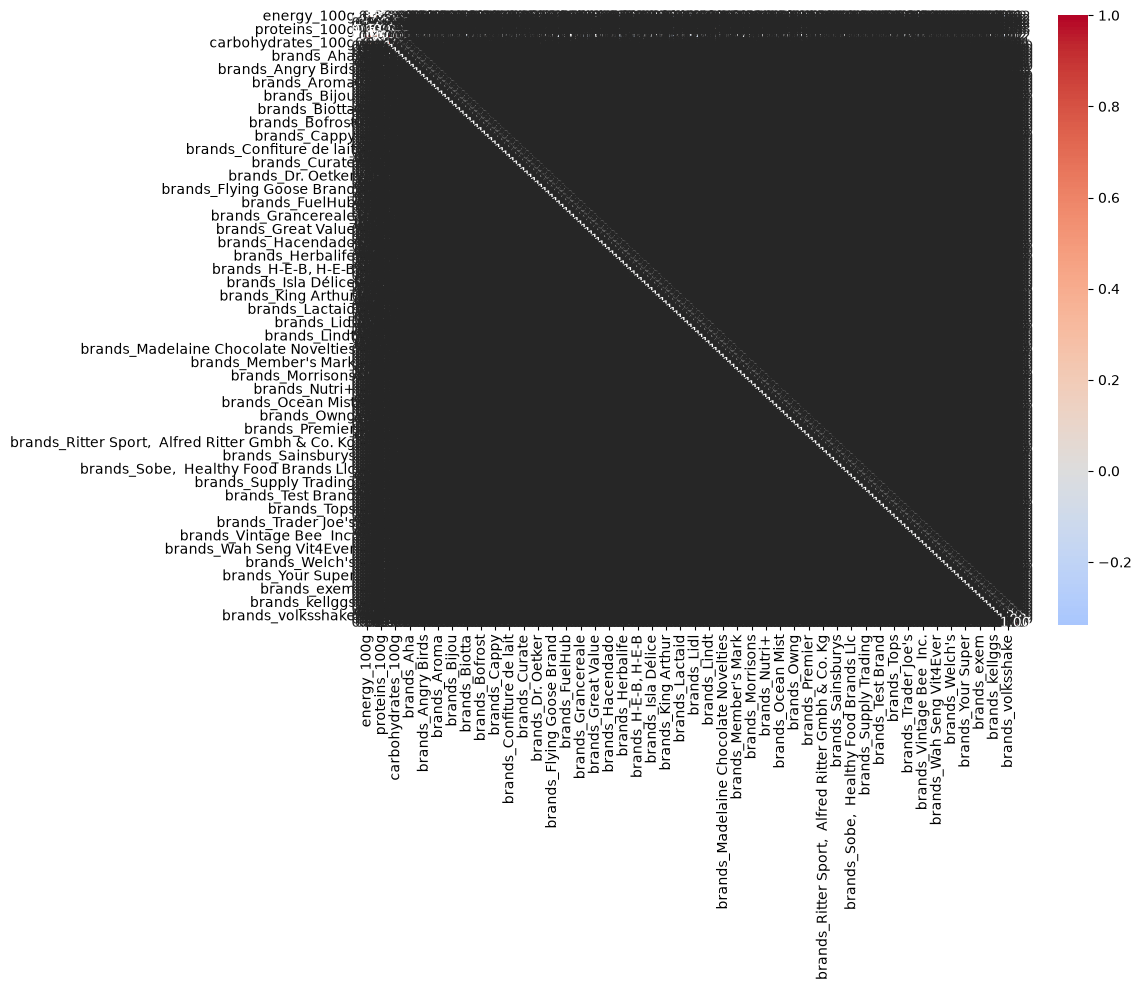

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [34]:

from logreg import (
    plot_correlation_matrix,
    compute_vif,
    train_ordinal_logit,
    evaluate_ordinal_model,
    run_lasso_logit,
)

df_train_full = X_train_final.copy()
df_train_full['nutriscore_grade'] = y_train_clean

corr = plot_correlation_matrix(df_train_full, cols_categorielles=cols_categorielles)
vif_data, vif_ok = compute_vif(df_train_full)

result, scaler = train_ordinal_logit(X_train_final, y_train_clean)
pred, probas = evaluate_ordinal_model(result, scaler, X_test_final, y_test_clean)

model, lasso_scaler = run_lasso_logit(X_train_final, y_train_clean)

# Ce qu'on obtient :
* Une heatmap de corrélation  --> voir si des variables covarient entre elles, dans ce cas pas besoin de prendre toutes les var mais selectionner les plus pertinentes
* Un tableau de VIF + liste des variables <5 :  Plus le VIF d'une variable est élevé (>5), plus elle est "expliquée" par les autres variables du modèle — donc potentiellement redondante,  signale un problème de multicolinéarité.
*  modèle ordinal : les coef du mod indique la direction de l'effet d'une variable sur le nutriscore. par exemple signifierait que plus il y a de sucre, plus la probabilité d'être dans une classe "pire" (vers 'e') augmente
4 seuils pour 5 catégories : positionne les frontières entre catégories sur l'échelle latente. Dans un modèle ordinal (contrairement à une régression linéaire classique), il n'y a pas une seule constante/intercept, mais plusieurs seuils de coupure (appelés thresholds ou cutpoints), un entre chaque paire de catégories adjacentes. C'est le principe même du modèle : il suppose qu'il existe une variable latente continue (un "score de risque" sous-jacent) et que tes 5 catégories observées (a, b, c, d, e) sont obtenues en découpant cette échelle continue à des seuils précis.                                                                                
a/b = -3.6532 : le seuil séparant la catégorie 'a' de 'b' sur l'échelle latente
b/c = 0.3839 : le seuil séparant 'b' de 'c'
c/d = 1.1577 : le seuil séparant 'c' de 'd'
d/e = 1.2086 : le seuil séparant 'd' de 'e'
Le fait que a/b, b/c, c/d, d/e soient croissants (-3.65-> 0.38 → 1.16 → 1.21) est cohérent avec la logique ordinale : les seuils doivent être ordonnés.
* Une accuracy = ici accuracy = 68% = pourcentage de prédictions correctes sur le jeu de test
* matrice de confusion pour évaluer ce modèle sur le test :  un tableau 5×5 (car 5 classes a-e) où chaque ligne est la vraie classe et chaque colonne la classe prédite ; la diagonale montre les bonnes prédictions cad cb de produits ont bien été classés, le reste les erreurs (et dans quel sens le modèle se trompe — ex. confond souvent 'b' avec 'c' cad cb de b ont été classés en c).
* Des coefficients par classe issus du Lasso logistique, pour aider à la sélection de variables : pour chacune des 5 classes (a, b, c, d, e), la liste des variables avec leur coefficient associé à cette classe précise (dans un modèle multinomial, chaque classe a son propre jeu de coefficients par rapport aux autres).Si 0 = doit etre enlevé du modele

Un coefficient positif pour saturated-fat_100g (2.4167, très significatif avec p=0.000) signifie que plus il y a de graisses saturées, plus le score latent augmente — donc plus la probabilité de basculer vers une catégorie "pire" (vers 'e') est élevée. C'est cohérent avec l'intuition nutritionnelle.

À l'inverse, proteins_100g a un coefficient négatif (-0.9199, significatif) : plus il y a de protéines, plus le score latent diminue, donc plus la probabilité de rester dans une bonne catégorie (vers 'a') est élevée. Ça aussi c'est cohérent.

En revanche fat_100g n'a pas l'air d'expliquer le nutriscore

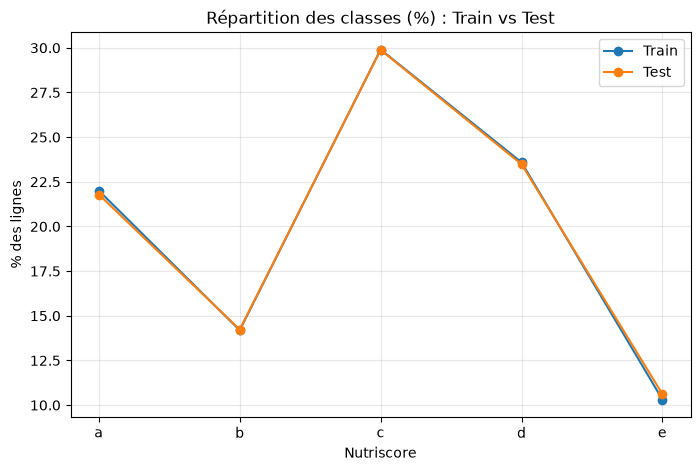

In [ ]:

ordre = ['a', 'b', 'c', 'd', 'e']
train_pct = y_train_clean.value_counts(normalize=True).reindex(ordre) * 100
test_pct = y_test_clean.value_counts(normalize=True).reindex(ordre) * 100

plt.figure(figsize=(8, 5))
plt.plot(ordre, train_pct.values, marker='o', label='Train')
plt.plot(ordre, test_pct.values, marker='o', label='Test')
plt.xlabel('Nutriscore')
plt.ylabel('% des lignes')
plt.title('Répartition des classes (%) : Train vs Test')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Accuracy sur train

ORDRE_NUTRISCORE = ["a", "b", "c", "d", "e"]
from sklearn.metrics import accuracy_score
X_train_scaled = pd.DataFrame(scaler.transform(X_train_clean), columns=X_train_clean.columns, index=X_train_clean.index)
probas_train = result.predict(X_train_scaled)
probas_train.columns = ORDRE_NUTRISCORE
pred_train = probas_train.idxmax(axis=1)
acc_train = accuracy_score(y_train_clean, pred_train)

# Accuracy sur test (déjà calculée dans evaluate_ordinal_model, on la refait ici pour l'avoir en variable)
acc_test = accuracy_score(y_test_clean, pred)  # `pred` vient de evaluate_ordinal_model

print(f"Accuracy train : {acc_train:.3f}")
print(f"Accuracy test : {acc_test:.3f}")

Accuracy train : 0.660
Accuracy test : 0.662


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

def plot_learning_curve_ordinal(X_train, y_train, X_test, y_test, ordre=ORDRE_NUTRISCORE, n_points=8, random_state=42):
    """
    Trace la learning curve d'un modèle ordinal en faisant varier
    la taille du jeu d'entraînement.
    """
    tailles = np.linspace(0.1, 1.0, n_points)
    train_scores = []
    test_scores = []
    n_samples_list = []

    rng = np.random.RandomState(random_state)

    for frac in tailles:
        n = int(frac * len(X_train))
        idx = rng.choice(X_train.index, size=n, replace=False)
        X_sub = X_train.loc[idx]
        y_sub = y_train.loc[idx]

        # entraînement sur le sous-échantillon
        result, scaler = train_ordinal_logit(X_sub, y_sub, ordre=ordre)

        # accuracy sur le sous-échantillon d'entraînement lui-même
        X_sub_scaled = pd.DataFrame(scaler.transform(X_sub), columns=X_sub.columns, index=X_sub.index)
        probas_train = result.predict(X_sub_scaled)
        probas_train.columns = ordre
        pred_train = probas_train.idxmax(axis=1)
        train_scores.append(accuracy_score(y_sub, pred_train))

        # accuracy sur le jeu de test (fixe, toujours le même)
        X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
        probas_test = result.predict(X_test_scaled)
        probas_test.columns = ordre
        pred_test = probas_test.idxmax(axis=1)
        test_scores.append(accuracy_score(y_test, pred_test))

        n_samples_list.append(n)

    plt.figure(figsize=(8, 5))
    plt.plot(n_samples_list, train_scores, marker='o', label='Train accuracy')
    plt.plot(n_samples_list, test_scores, marker='o', label='Test accuracy')
    plt.xlabel("Nombre d'échantillons d'entraînement")
    plt.ylabel("Accuracy")
    plt.title("Learning curve — modèle ordinal")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return n_samples_list, train_scores, test_scores

Optimization terminated successfully.
         Current function value: 0.912824
         Iterations: 38
         Function evaluations: 39
         Gradient evaluations: 39
                             OrderedModel Results                             
Dep. Variable:       nutriscore_grade   Log-Likelihood:                -4887.3
Model:                   OrderedModel   AIC:                             9799.
Method:            Maximum Likelihood   BIC:                             9878.
Date:                Mon, 24 Aug 2026                                         
Time:                        17:11:05                                         
No. Observations:                5354                                         
Df Residuals:                    5342                                         
Df Model:                           8                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------

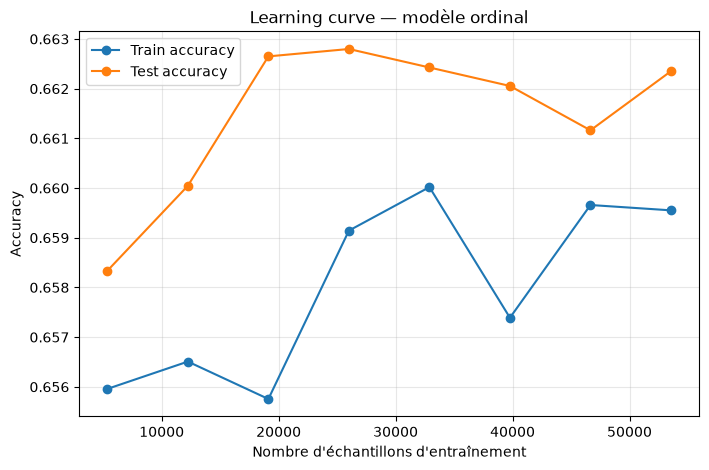

In [ ]:
n_samples_list, train_scores, test_scores = plot_learning_curve_ordinal(
    X_train_clean, y_train_clean, X_test_clean, y_test_clean
)